# 05 — Unsupervised Segmentation (data-driven archetypes)

The payoff of the feature work: assemble the full tabular feature set + the 384-d text embeddings,
reduce with PCA, cluster with **KMeans** (chosen by silhouette) and **HDBSCAN** (density), visualise with
**UMAP**, then profile and **name the data-driven locality archetypes** — the empirical replacement for
hand-coded personas.

Reads `artifacts/features_geo_graph.parquet` + `artifacts/embeddings.npz`;
writes `artifacts/localities_segmented.parquet` + `artifacts/kmeans.joblib` + a UMAP plot.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

ART = Path.cwd() / "artifacts"
df = pd.read_parquet(ART / "features_geo_graph.parquet").reset_index(drop=True)
emb = np.load(ART / "embeddings.npz", allow_pickle=True)
combined = emb["combined"]  # (1001, 384)
print("Rows:", len(df), "| embedding:", combined.shape)

Rows: 1001 | embedding: (1001, 384)


In [2]:
# --- Assemble the feature matrix: scaled tabular features + PCA-compressed text embedding ---
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

TAB = [
    "res_avg_buy", "buy_rent_ratio", "price_spread_pct",
    "total_amenities", "amenity_diversity", "infra_completeness", "retail_civic_balance",
    "num_educational_institute", "num_hospital", "num_shopping_centre",
    "num_transportation_hub", "num_commercial_hub", "num_tourist_spot",
    "num_employers", "primary_sector_score",
    "sector_information_technology", "sector_finance_and_banking", "sector_consulting",
    "sector_manufacturing_and_industry", "sector_government_and_public_sector",
    "sector_retail_and_commercial", "sector_healthcare_and_pharma",
    "airport_min", "dist_to_city_centroid_km", "knn_density_km",
    "graph_degree", "graph_pagerank", "graph_clustering", "belt_size",
]
TAB = [c for c in TAB if c in df.columns]
X_tab = df[TAB].apply(pd.to_numeric, errors="coerce")
X_tab["is_metro_connected"] = df["is_metro_connected"].astype(float)

# median-impute + standardise the tabular block
X_tab_s = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X_tab))

# compress the 384-d embedding to 30 PCs so it doesn't swamp the ~30 tabular features
emb_pca = PCA(n_components=30, random_state=42).fit_transform(StandardScaler().fit_transform(combined))

# combine, then a final PCA to denoise the joint space
X = np.hstack([X_tab_s, emb_pca])
Xp = PCA(n_components=25, random_state=42).fit_transform(X)
print("Tabular features used:", len(TAB) + 1, "| joint matrix:", X.shape, "-> PCA", Xp.shape)

Tabular features used: 30 | joint matrix: (1001, 60) -> PCA (1001, 25)


In [3]:
# --- KMeans: choose k by silhouette ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(4, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xp)
    scores[k] = silhouette_score(Xp, km.labels_)
best_k = max(scores, key=scores.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in scores.items()})
print("Best k =", best_k, "(silhouette %.3f)" % scores[best_k])

import joblib
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xp)
df["cluster"] = kmeans.labels_
joblib.dump(kmeans, ART / "kmeans.joblib")

Silhouette by k: {4: 0.252, 5: 0.258, 6: 0.268, 7: 0.269, 8: 0.276, 9: 0.28, 10: 0.285}
Best k = 10 (silhouette 0.285)


['C:\\Users\\singh\\Desktop\\GOATLife\\notebooks\\artifacts\\kmeans.joblib']

In [4]:
# --- HDBSCAN (density-based) for comparison ---
import hdbscan
hdb = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5).fit(Xp)
df["hdbscan_cluster"] = hdb.labels_
n_hdb = len(set(hdb.labels_)) - (1 if -1 in hdb.labels_ else 0)
print("HDBSCAN clusters:", n_hdb, "| noise:", int((hdb.labels_ == -1).sum()))

# stability check: re-run KMeans on a 80% subsample, measure agreement (ARI) with full labels
from sklearn.metrics import adjusted_rand_score
rng = np.random.RandomState(0)
idx = rng.choice(len(Xp), int(0.8 * len(Xp)), replace=False)
km2 = KMeans(n_clusters=df["cluster"].nunique(), n_init=10, random_state=7).fit(Xp[idx])
ari = adjusted_rand_score(df["cluster"].values[idx], km2.labels_)
print("KMeans stability (ARI, full vs 80%% subsample): %.3f" % ari)

HDBSCAN clusters: 4 | noise: 53
KMeans stability (ARI, full vs 80% subsample): 0.961


In [5]:
# --- Profile + name each KMeans cluster ---
profile_cols = ["res_avg_buy", "total_amenities", "num_employers",
                "sector_information_technology", "graph_degree", "knn_density_km",
                "num_educational_institute", "is_metro_connected"]
profile_cols = [c for c in profile_cols if c in df.columns]
prof = df.groupby("cluster")[profile_cols].mean(numeric_only=True).round(2)
prof["n"] = df["cluster"].value_counts().sort_index()
print(prof.to_string())

# Data-driven naming: label each cluster by its most distinctive features (z vs global mean).
NAME_COLS = ["res_avg_buy", "total_amenities", "num_employers",
             "sector_information_technology", "sector_manufacturing_and_industry",
             "sector_government_and_public_sector", "num_educational_institute",
             "num_hospital", "knn_density_km", "graph_degree", "infra_completeness",
             "is_metro_connected"]
NAME_COLS = [c for c in NAME_COLS if c in df.columns]
zmat = (df.groupby("cluster")[NAME_COLS].mean() - df[NAME_COLS].mean()) / df[NAME_COLS].std(ddof=0)

PHRASE = {
    "res_avg_buy": "Premium", "total_amenities": "Amenity-rich", "num_employers": "Employer-dense",
    "sector_information_technology": "IT-employment", "sector_manufacturing_and_industry": "Industrial",
    "sector_government_and_public_sector": "Govt-linked", "num_educational_institute": "Education-dense",
    "num_hospital": "Healthcare-rich", "knn_density_km": "Sparse/peripheral",
    "graph_degree": "Well-connected", "infra_completeness": "Full-infra", "is_metro_connected": "Metro",
}

def name_cluster(cz):
    top = cz.sort_values(ascending=False)
    feats = [PHRASE[f] for f in top.index[:2] if cz[f] > 0.4 and f in PHRASE]
    return " · ".join(feats) if feats else "Average / Mixed"

names = {c: name_cluster(zmat.loc[c]) for c in zmat.index}
df["cluster_label"] = df["cluster"].map(names)
# guarantee uniqueness if two clusters get the same phrase
seen = {}
uniq = {}
for c in sorted(names):
    base = names[c]
    seen[base] = seen.get(base, 0) + 1
    uniq[c] = base if seen[base] == 1 else f"{base} ({seen[base]})"
df["archetype_ml"] = df["cluster"].map(uniq)
print()
print("Data-driven archetypes (KMeans k=%d, named by distinctive features):" % df["cluster"].nunique())
print(df["archetype_ml"].value_counts().to_string())

         res_avg_buy  total_amenities  num_employers  sector_information_technology  graph_degree  knn_density_km  num_educational_institute  is_metro_connected    n
cluster                                                                                                                                                              
0           29011.11            13.23           4.70                           0.48          1.85            1.11                       2.15                0.93   84
1           19971.79             4.41           0.00                            NaN          1.64            2.68                       0.83                0.00  197
2           19867.91            16.04           3.71                           0.52          2.09            1.07                       3.50                0.93   92
3           10538.36            15.07           4.55                           0.82          1.19            2.04                       3.12                0.89   95
4   

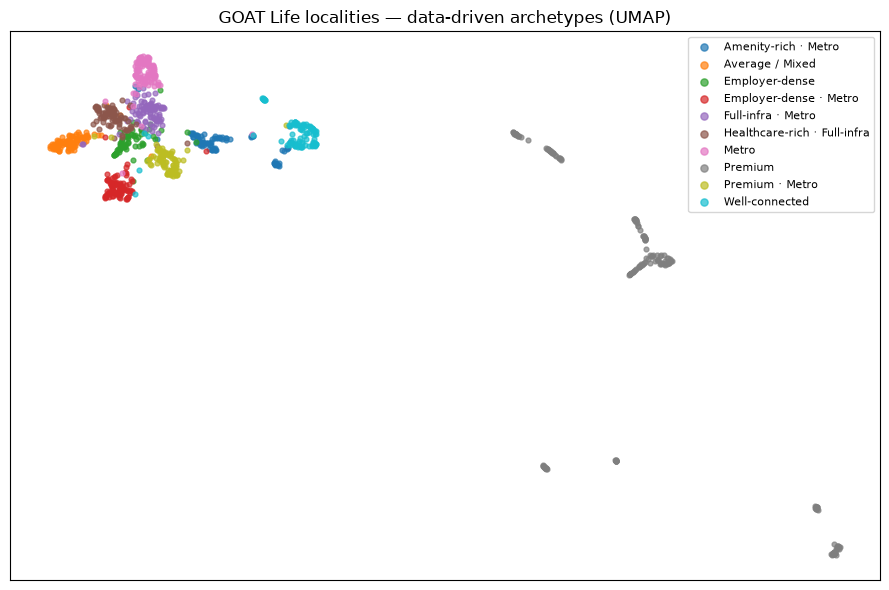

Saved UMAP plot -> artifacts/umap_archetypes.png


In [6]:
# --- UMAP 2-D visualisation coloured by archetype ---
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
xy = reducer.fit_transform(Xp)
df["umap_x"], df["umap_y"] = xy[:, 0], xy[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
for name, grp in df.groupby("archetype_ml"):
    ax.scatter(grp["umap_x"], grp["umap_y"], s=12, alpha=0.7, label=name)
ax.set_title("GOAT Life localities — data-driven archetypes (UMAP)")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=8, markerscale=1.5, loc="best")
plt.tight_layout()
plt.savefig(ART / "umap_archetypes.png", dpi=110)
plt.show()
print("Saved UMAP plot -> artifacts/umap_archetypes.png")

In [7]:
# --- Save segmented dataset ---
out = ART / "localities_segmented.parquet"
df.to_parquet(out, index=False)
print("Saved", df.shape[0], "rows x", df.shape[1], "cols ->", out.relative_to(Path.cwd()))
print("New columns: cluster, hdbscan_cluster, archetype_ml, umap_x, umap_y")

Saved 1001 rows x 76 cols -> artifacts\localities_segmented.parquet
New columns: cluster, hdbscan_cluster, archetype_ml, umap_x, umap_y


## Output
`artifacts/localities_segmented.parquet` + `kmeans.joblib` + `umap_archetypes.png` — every locality now
carries a **data-driven archetype** derived from its full feature + embedding profile, plus UMAP coords.

**Next:** `06_supervised_imputation_drivers.ipynb` — model-impute the missing prices (LightGBM + nested CV)
and run SHAP to surface what actually drives affluence.